In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

In [73]:
def generate_dataset(samples_per_class=150):
    np.random.seed(42)
    c1 = np.random.randn(samples_per_class, 2) + np.array([0, 0])
    c2 = np.random.randn(samples_per_class, 2) + np.array([4, 4])
    c3 = np.random.randn(samples_per_class, 2) + np.array([8, 0])
    c4 = np.random.randn(samples_per_class, 2) + np.array([4, -4])
    X = np.vstack([c1, c2, c3, c4])
    y = np.array([0]*samples_per_class + [1]*samples_per_class + [2]*samples_per_class + [3]*samples_per_class)
    return X, y

X, y = generate_dataset()

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.reshape(-1, 1))


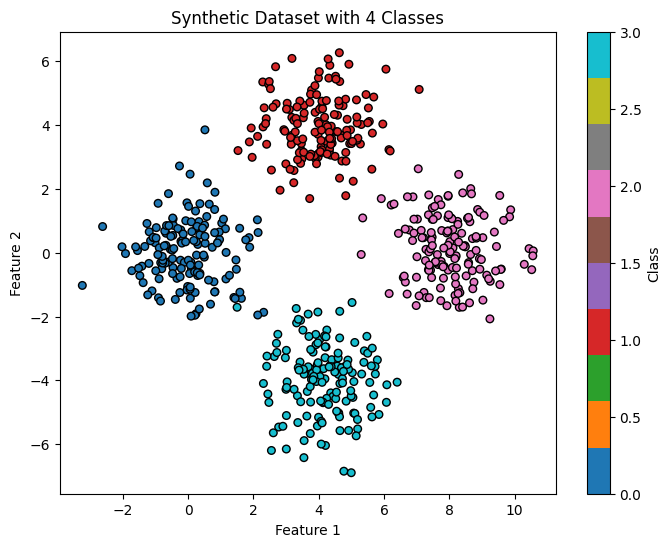

In [74]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y, cmap="tab10", s=30, edgecolors="k")
plt.title("Synthetic Dataset with 4 Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")
plt.show()

In [75]:
from sklearn.model_selection import train_test_split

class CustomNN:
    def __init__(self, input_dim=2, hidden1=12, hidden2=10, output_dim=4, lr=0.15):
        self.lr = lr
        self.W1 = np.random.randn(input_dim, hidden1) * 0.1
        self.W2 = np.random.randn(hidden1, hidden2) * 0.1
        self.W3 = np.random.randn(hidden2, output_dim) * 0.1

    def relu(self, x, der=False):
        if der:
            return (x > 0).astype(float)
        return np.maximum(0, x)

    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        self.h1 = self.relu(np.dot(X, self.W1))
        self.h2 = self.relu(np.dot(self.h1, self.W2))
        self.out = self.softmax(np.dot(self.h2, self.W3))
        return self.out

    def backprop(self, X, Y, pred):
        error = pred - Y
        dW3 = self.h2.T.dot(error)
        dh2 = error.dot(self.W3.T) * self.relu(self.h2, der=True)
        dW2 = self.h1.T.dot(dh2)
        dh1 = dh2.dot(self.W2.T) * self.relu(self.h1, der=True)
        dW1 = X.T.dot(dh1)

        self.W3 -= self.lr * dW3
        self.W2 -= self.lr * dW2
        self.W1 -= self.lr * dW1

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def train(self, X, Y, epochs=100):
        # Split train/test
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

        train_loss, test_loss = [], []
        train_acc, test_acc = [], []

        for i in range(epochs):
            # ---- Train ----
            pred_train = self.forward(X_train)
            self.backprop(X_train, Y_train, pred_train)

            # Loss
            loss_train = np.mean((Y_train - pred_train)**2)
            loss_test = np.mean((Y_test - self.forward(X_test))**2)

            # Accuracy
            y_true_train = np.argmax(Y_train, axis=1)
            y_hat_train = np.argmax(pred_train, axis=1)
            acc_train = np.mean(y_true_train == y_hat_train)

            y_true_test = np.argmax(Y_test, axis=1)
            y_hat_test = np.argmax(self.forward(X_test), axis=1)
            acc_test = np.mean(y_true_test == y_hat_test)

            # Save history
            train_loss.append(loss_train)
            test_loss.append(loss_test)
            train_acc.append(acc_train)
            test_acc.append(acc_test)

            if i % 10 == 0:
                print(f"Epoch {i}, Train Acc={acc_train*100:.2f}%, Test Acc={acc_test*100:.2f}%")

        return train_loss, test_loss, train_acc, test_acc


In [76]:
def plot_curves(train_loss, test_loss, train_acc, test_acc):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12, 5))

    # Loss curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, test_loss, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()

    # Accuracy curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, test_acc, label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('Accuracy Curve')
    plt.legend()

    plt.show()


Epoch 0, Train Acc=33.96%, Test Acc=26.67%
Epoch 10, Train Acc=34.79%, Test Acc=28.33%
Epoch 20, Train Acc=35.21%, Test Acc=26.67%
Epoch 30, Train Acc=35.00%, Test Acc=26.67%
Epoch 40, Train Acc=35.00%, Test Acc=26.67%
Epoch 50, Train Acc=35.00%, Test Acc=26.67%
Epoch 60, Train Acc=35.00%, Test Acc=26.67%
Epoch 70, Train Acc=34.58%, Test Acc=26.67%
Epoch 80, Train Acc=35.00%, Test Acc=26.67%
Epoch 90, Train Acc=35.21%, Test Acc=27.50%
Epoch 100, Train Acc=35.00%, Test Acc=26.67%
Epoch 110, Train Acc=35.00%, Test Acc=26.67%
Epoch 120, Train Acc=34.79%, Test Acc=26.67%
Epoch 130, Train Acc=35.00%, Test Acc=26.67%
Epoch 140, Train Acc=35.00%, Test Acc=26.67%
Epoch 150, Train Acc=35.00%, Test Acc=26.67%
Epoch 160, Train Acc=35.00%, Test Acc=26.67%
Epoch 170, Train Acc=35.00%, Test Acc=26.67%
Epoch 180, Train Acc=35.00%, Test Acc=26.67%
Epoch 190, Train Acc=35.00%, Test Acc=26.67%


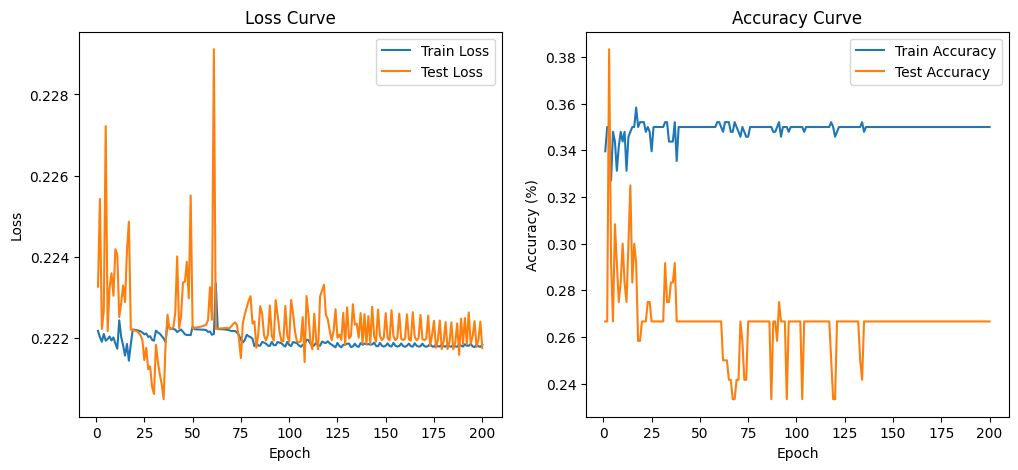

In [77]:
nn = CustomNN(input_dim=X.shape[1], hidden1=12, hidden2=10, output_dim=Y.shape[1], lr=0.15)

train_loss, test_loss, train_acc, test_acc = nn.train(X, Y, epochs=200)

plot_curves(train_loss, test_loss, train_acc, test_acc)
